intallations

In [1]:
!pip install torch torchvision matplotlib scikit-learn transformers

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/py

imports

In [2]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

drive + paths

In [3]:
#from google.colab import drive
# drive.mount('/content/drive')

# Clone repo
#!git clone https://github.com/AvitalSkop/genai-project.git
%cd genai-project

base_dir = "/home/workspace/gottrey/genai-project/data/split"

train_dir = f"{base_dir}/train"
val_dir   = f"{base_dir}/val"
test_dir  = f"{base_dir}/test"

real_test_dir = "/home/workspace/gottrey/genai-project/data/real_test"

[Errno 2] No such file or directory: 'genai-project'
/home/workspace/gottrey/genai-project


transforms

In [4]:
"""
    train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.8, 1.2)
    ),
    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.3
    ),
    transforms.GaussianBlur(kernel_size=5),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
"""

from torchvision import transforms
import torch

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    # 🔄 גיאומטריה עדינה
    transforms.RandomRotation(15),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.4),

    # 💡 תאורה וצבע (הרבה יותר עדין)
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),

    # 🌫 blur עדין
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2)),

    transforms.ToTensor(),

    # 🔊 רעש אמיתי
    transforms.Lambda(lambda x: x + 0.03 * torch.randn_like(x)),

    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

datasets

Classes: ['clean', 'finished', 'full']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2302303..1.0677397].


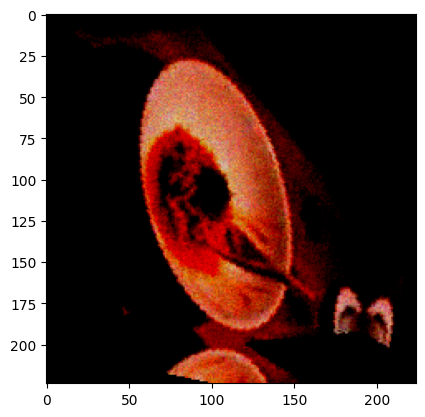

In [ ]:
import matplotlib.pyplot as plt

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

real_dataset = datasets.ImageFolder(real_test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=8, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=8, num_workers=0)
real_loader  = DataLoader(real_dataset, batch_size=8, num_workers=0)

print("Classes:", train_dataset.classes)

for images, _ in train_loader:
    plt.imshow(images[0].permute(1,2,0))
    plt.show()
    break

model

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# model = models.resnet18(pretrained=True)
# model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))
# model = model.to(device)
from torchvision.models import resnet50, ResNet50_Weights # Import resnet50 and its weights
import torch.nn as nn

# Load ResNet50 with its default weights
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# 🔥 freeze backbone
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/gottrey/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 54.0MB/s]


loss + optimizer

In [7]:
# criterion = nn.CrossEntropyLoss()
from collections import Counter
import torch

labels = [label for _, label in train_dataset.samples]
class_counts = Counter(labels)

total = sum(class_counts.values())
class_weights = [total / class_counts[i] for i in range(len(class_counts))]

class_weights = torch.tensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

train + eval

In [8]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val = 0
patience = 10
counter = 0

def train_epoch(model, loader, optimizer, criterion, device):
  model.train()

  total_loss = 0
  correct = 0
  total = 0

  for i, (x, y) in enumerate(loader):
        #print(f"Loaded batch {i}")
        break

  for x, y in loader:
      x, y = x.to(device), y.to(device)

      optimizer.zero_grad()

      outputs = model(x)
      # print("model ok")
      loss = criterion(outputs, y)

      loss.backward()
      optimizer.step()

      total_loss += loss.item() * x.size(0)
      preds = outputs.argmax(1)

      correct += (preds == y).sum().item()
      total += y.size(0)

  avg_loss = total_loss / total
  acc = correct / total

  return avg_loss, acc


def eval_model(model, loader, criterion, device):
  model.eval()

  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
      for x, y in loader:
          x, y = x.to(device), y.to(device)

          outputs = model(x)
          loss = criterion(outputs, y)

          total_loss += loss.item() * x.size(0)

          preds = outputs.argmax(1)
          correct += (preds == y).sum().item()
          total += y.size(0)

  avg_loss = total_loss / total
  acc = correct / total

  return avg_loss, acc

training

In [9]:
epochs = 50

print("Starting training...")

for epoch in range(epochs):
  train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
  val_loss, val_acc = eval_model(model, val_loader, criterion, device)

  train_losses.append(train_loss)
  train_accuracies.append(train_acc)
  val_losses.append(val_loss)
  val_accuracies.append(val_acc)

  print(f"\nEpoch {epoch+1}")
  print(f"Train Loss: {train_loss:.3f}")
  print(f"Train Acc:  {train_acc:.3f}")
  print(f"Val Loss:   {val_loss:.3f}")
  print(f"Val Acc:    {val_acc:.3f}")

  # EARLY STOPPING
  if val_acc > best_val:
      best_val = val_acc
      counter = 0
      torch.save(model.state_dict(), "best_model.pth")
      print("saved best model")
  else:
      counter += 1
      print(f"no improvement ({counter}/{patience})")

  if counter >= patience:
      print("Early stopping triggered")
      break

model.load_state_dict(torch.load("best_model.pth"))
print("Loaded best model")

Starting training...


OutOfMemoryError: CUDA out of memory. Tried to allocate 50.00 MiB. GPU 0 has a total capacity of 10.58 GiB of which 20.88 MiB is free. Process 3544007 has 7.26 GiB memory in use. Process 989252 has 2.79 GiB memory in use. Process 1067271 has 156.00 MiB memory in use. Process 1080099 has 352.00 MiB memory in use. Of the allocated memory 149.12 MiB is allocated by PyTorch, and 18.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

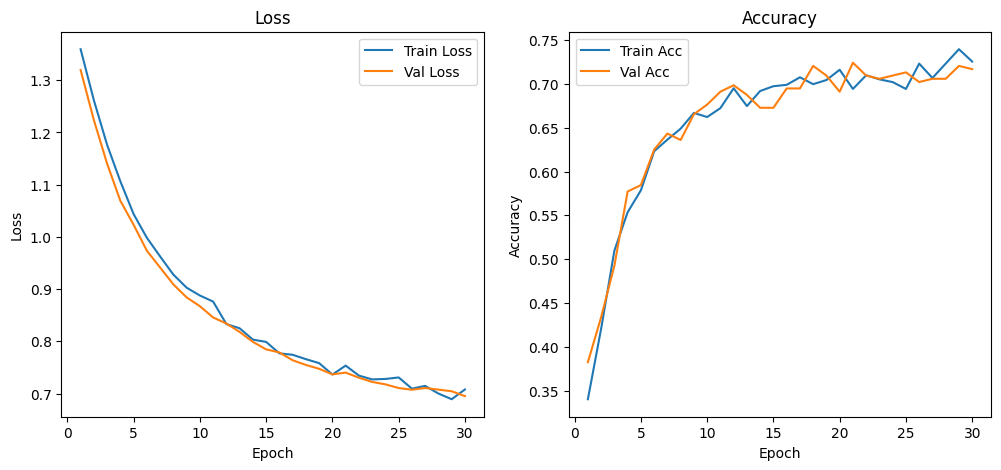

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

synthetic Test

In [ ]:
synthetic_loss, synthetic_acc = eval_model(model, test_loader, criterion, device)

print(f"\nSynthetic Test Loss: {synthetic_loss:.3f}")
print(f"Synthetic Test Accuracy: {synthetic_acc:.3f}")


Synthetic Test Loss: 0.721
Synthetic Test Accuracy: 0.704


Real Test

In [ ]:
real_loss, real_acc = eval_model(model, real_loader, criterion, device)

print(f"\nReal Test Loss: {real_loss:.3f}")
print(f"Real Test Accuracy: {real_acc:.3f}")


Real Test Loss: 1.277
Real Test Accuracy: 0.446


Confusion Matrix - function

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_preds)

Synthetic CM

In [ ]:
y_true, y_pred = get_predictions(model, test_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Synthetic Test")
plt.show()

Real CM

In [ ]:
y_true, y_pred = get_predictions(model, real_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=real_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Real Test")
plt.show()

FT

In [ ]:
print("\n🔓 Starting Fine-Tuning...")

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

best_val = 0
counter = 0

ft_epochs = 15

for epoch in range(ft_epochs):

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_model(model, val_loader, criterion, device)

    print(f"\n[FT] Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.3f}")
    print(f"Train Acc:  {train_acc:.3f}")
    print(f"Val Loss:   {val_loss:.3f}")
    print(f"Val Acc:    {val_acc:.3f}")

    if val_acc > best_val:
        best_val = val_acc
        counter = 0
        torch.save(model.state_dict(), "best_model_ft.pth")
        print("saved FT best model")
    else:
        counter += 1

    if counter >= patience:
        print("FT Early stopping")
        break

model.load_state_dict(torch.load("best_model_ft.pth"))
print("Loaded FT best model")

synthetic_loss_ft, synthetic_acc_ft = eval_model(model, test_loader, criterion, device) # Renamed variables for clarity

print(f"\n[FT] Synthetic Accuracy: {synthetic_acc_ft:.3f}")

real_loss_ft, real_acc_ft = eval_model(model, real_loader, criterion, device) # Renamed variables for clarity

print(f"\n[FT] Real Accuracy: {real_acc_ft:.3f}")

# The following lines related to CLIP are commented out as they refer to undefined functions/variables.
# If you wish to evaluate CLIP, you would need to implement its loading and evaluation separately.
# plt.title("Confusion Matrix - REAL (After FT)")
# clip_acc_syn = evaluate_clip(test_loader)
# print(f"\nCLIP Accuracy (SYNTHETIC): {clip_acc_syn:.3f}")

print("\n=== FINAL COMPARISON (After Fine-Tuning) ===")

# Assuming synthetic_acc and real_acc still hold values from before fine-tuning
print(f"ResNet (before FT) Synthetic: {synthetic_acc:.3f}")
print(f"ResNet (before FT) Real:      {real_acc:.3f}")

print(f"ResNet (after FT) Synthetic:  {synthetic_acc_ft:.3f}")
print(f"ResNet (after FT) Real:       {real_acc_ft:.3f}")

# print(f"CLIP Synthetic:               {clip_acc_syn:.3f}")
# print(f"CLIP Real:                    {clip_acc_real:.3f}")
